## Statistical Significance Analysis

This notebook loads pre-trained models and saved predictions from the modeling notebook and runs statistical tests on them. No models are retrained here.

### Section 1: Setup and Load

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import (
    mannwhitneyu, kruskal, ks_2samp,
    chi2_contingency, expon, gamma, lognorm, norm, weibull_min
)
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Load saved predictions and labels
y_test     = np.load('../models/y_test.npy')
y_prob_lr  = np.load('../models/y_prob_lr.npy')
y_prob_dt  = np.load('../models/y_prob_dt.npy')
y_prob_rf  = np.load('../models/y_prob_rf.npy')
y_prob_xgb = np.load('../models/y_prob_xgb.npy')
y_pred_lr  = np.load('../models/y_pred_lr.npy')
y_pred_dt  = np.load('../models/y_pred_dt.npy')
y_pred_rf  = np.load('../models/y_pred_rf.npy')
y_pred_xgb = np.load('../models/y_pred_xgb.npy')

# Load cleaned dataset
df = pd.read_csv('../outputs/diabetes_clean.csv', keep_default_na=False)

print("Loaded successfully.")
print(f"Test set size: {len(y_test)}")
print(f"AUC check - LR: {roc_auc_score(y_test, y_prob_lr):.4f}, RF: {roc_auc_score(y_test, y_prob_rf):.4f}, XGB: {roc_auc_score(y_test, y_prob_xgb):.4f}")

Loaded successfully.
Test set size: 13995
AUC check - LR: 0.6414, RF: 0.6442, XGB: 0.6438


**The test set contains 13,995 patients.** AUC scores across models are close together: Logistic Regression (0.6414), Random Forest (0.6442), and XGBoost (0.6438). This confirms the models are loaded correctly and that all three perform at a similar level before any formal comparison.

### Section 2: DeLong Test - Pairwise AUC Comparison

The DeLong test compares two AUC scores on the same test set and determines whether the difference is statistically significant. It accounts for the correlation between the two models since they are evaluated on the same patients.

In [2]:
def delong_roc_variance(ground_truth, predictions):
    pos_scores = predictions[ground_truth == 1]
    neg_scores = predictions[ground_truth == 0]
    n1 = len(pos_scores)
    n0 = len(neg_scores)

    v10 = np.array([
        np.mean(p > neg_scores) + 0.5 * np.mean(p == neg_scores)
        for p in pos_scores
    ])
    v01 = np.array([
        np.mean(n < pos_scores) + 0.5 * np.mean(n == pos_scores)
        for n in neg_scores
    ])

    auc = np.mean(v10)
    var = (np.var(v10, ddof=1) / n1) + (np.var(v01, ddof=1) / n0)
    return auc, var, v10, v01


def delong_test(y_true, y_prob_a, y_prob_b, name_a, name_b):
    auc_a, var_a, v10_a, v01_a = delong_roc_variance(y_true, y_prob_a)
    auc_b, var_b, v10_b, v01_b = delong_roc_variance(y_true, y_prob_b)

    n1 = (y_true == 1).sum()
    n0 = (y_true == 0).sum()

    cov = (np.cov(v10_a, v10_b)[0, 1] / n1) + (np.cov(v01_a, v01_b)[0, 1] / n0)
    se = np.sqrt(var_a + var_b - 2 * cov)
    z = (auc_a - auc_b) / se if se > 0 else 0.0
    p = 2 * (1 - stats.norm.cdf(abs(z)))

    return {
        'Model A': name_a,
        'Model B': name_b,
        'AUC A': round(auc_a, 4),
        'AUC B': round(auc_b, 4),
        'AUC Diff': round(auc_a - auc_b, 4),
        'Z-stat': round(z, 4),
        'P-value': round(p, 4),
        'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'
    }

In [3]:
model_probs = {
    'Logistic Regression': y_prob_lr,
    'Decision Tree':       y_prob_dt,
    'Random Forest':       y_prob_rf,
    'XGBoost':             y_prob_xgb
}

model_names = list(model_probs.keys())
delong_results = []

for i in range(len(model_names)):
    for j in range(i + 1, len(model_names)):
        name_a = model_names[i]
        name_b = model_names[j]
        result = delong_test(
            y_test,
            model_probs[name_a],
            model_probs[name_b],
            name_a, name_b
        )
        delong_results.append(result)

delong_df = pd.DataFrame(delong_results)
print("DeLong Pairwise AUC Comparison:")
print(delong_df.to_string(index=False))

DeLong Pairwise AUC Comparison:
            Model A       Model B  AUC A  AUC B  AUC Diff  Z-stat  P-value Significant (p<0.05)
Logistic Regression Decision Tree 0.6414 0.6277    0.0137  2.6034   0.0092                  Yes
Logistic Regression Random Forest 0.6414 0.6442   -0.0028 -0.6483   0.5168                   No
Logistic Regression       XGBoost 0.6414 0.6438   -0.0024 -0.7375   0.4608                   No
      Decision Tree Random Forest 0.6277 0.6442   -0.0165 -2.9454   0.0032                  Yes
      Decision Tree       XGBoost 0.6277 0.6438   -0.0161 -3.2490   0.0012                  Yes
      Random Forest       XGBoost 0.6442 0.6438    0.0004  0.0931   0.9258                   No


**Random Forest and XGBoost are statistically equivalent in AUC** (p = 0.93), and both are also statistically equivalent to Logistic Regression (p = 0.52 and p = 0.46 respectively). The AUC differences among these three models are under 0.003, which is too small to be meaningful.

Decision Tree is the clear outlier. Its AUC (0.6277) is significantly lower than both Random Forest (p = 0.003) and XGBoost (p = 0.001), confirmed by the DeLong test. The gap of roughly 0.016 AUC points reflects a real performance difference, not random variation. Decision Tree should be excluded from final model selection based on this result.

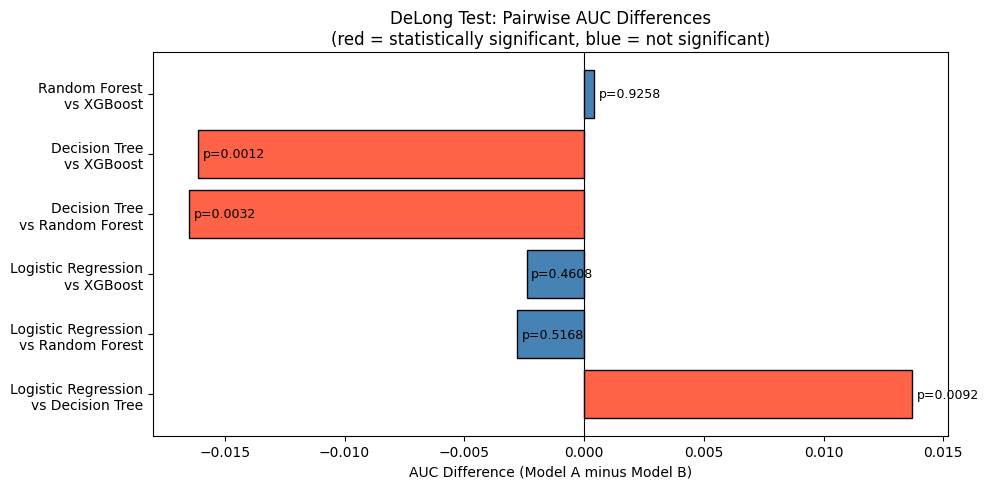

In [4]:
fig, ax = plt.subplots(figsize=(10, 5))

pairs = [f"{r['Model A']}\nvs {r['Model B']}" for _, r in delong_df.iterrows()]
diffs = delong_df['AUC Diff'].values
pvals = delong_df['P-value'].values
colors = ['tomato' if s == 'Yes' else 'steelblue' for s in delong_df['Significant (p<0.05)']]

bars = ax.barh(pairs, diffs, color=colors, edgecolor='black')
ax.axvline(0, color='black', linewidth=0.8)

for bar, p in zip(bars, pvals):
    label = f"p={p}" if p >= 0.001 else "p<0.001"
    ax.text(bar.get_width() + 0.0002, bar.get_y() + bar.get_height() / 2,
            label, va='center', fontsize=9)

ax.set_xlabel('AUC Difference (Model A minus Model B)')
ax.set_title('DeLong Test: Pairwise AUC Differences\n(red = statistically significant, blue = not significant)')
plt.tight_layout()
plt.show()

The chart shows AUC difference on the x-axis for each model pair. Red bars mark pairs where the difference is statistically significant (p < 0.05) and blue bars mark pairs where it is not. All Decision Tree comparisons are red and negative, meaning Decision Tree consistently underperforms. All three comparisons involving Random Forest and XGBoost against each other and against Logistic Regression are blue and near zero, confirming those models perform at the same level.

### Section 3: Mann-Whitney U Test - Feature Distributions vs Readmission

Mann-Whitney U tests whether the distribution of a numerical feature differs significantly between readmitted and not-readmitted patients. It is the non-parametric alternative to an independent samples t-test and does not assume normality, making it appropriate for the right-skewed distributions in this dataset.

In [5]:
num_features = [
    'time_in_hospital', 'num_lab_procedures', 'num_medications',
    'number_outpatient', 'number_emergency', 'number_inpatient',
    'number_diagnoses', 'total_prior_visits', 'num_med_changes'
]

group_0 = df[df['readmitted'] == 0]
group_1 = df[df['readmitted'] == 1]

mw_results = []
for col in num_features:
    stat, p = mannwhitneyu(group_1[col], group_0[col], alternative='two-sided')
    mw_results.append({
        'Feature': col,
        'Mean (Not Readmitted)':    round(group_0[col].mean(), 3),
        'Mean (Readmitted)':        round(group_1[col].mean(), 3),
        'Median (Not Readmitted)':  round(group_0[col].median(), 3),
        'Median (Readmitted)':      round(group_1[col].median(), 3),
        'U-statistic':              round(stat, 1),
        'P-value':                  round(p, 6),
        'Significant (p<0.05)':     'Yes' if p < 0.05 else 'No'
    })

mw_df = pd.DataFrame(mw_results).sort_values('P-value')
print("Mann-Whitney U Test: Feature Distributions vs 30-Day Readmission")
print(mw_df.to_string(index=False))

Mann-Whitney U Test: Feature Distributions vs 30-Day Readmission
           Feature  Mean (Not Readmitted)  Mean (Readmitted)  Median (Not Readmitted)  Median (Readmitted)  U-statistic  P-value Significant (p<0.05)
  time_in_hospital                  4.222              4.797                      3.0                  4.0  223874549.5  0.00000                  Yes
num_lab_procedures                 42.675             44.915                     44.0                 46.0  213030769.0  0.00000                  Yes
   num_medications                 15.571             16.626                     14.0                 15.0  217125457.5  0.00000                  Yes
  number_emergency                  0.099              0.150                      0.0                  0.0  205432141.0  0.00000                  Yes
  number_diagnoses                  7.195              7.513                      8.0                  8.0  216462658.0  0.00000                  Yes
  number_inpatient                 

**All nine features are significantly associated with 30-day readmission** (all p < 0.0001). The strongest separators by median difference are `number_inpatient` (median 0 vs 0, but mean 0.157 vs 0.369) and `time_in_hospital` (median 3 vs 4 days). Patients who were readmitted had more prior inpatient visits, longer hospital stays, more lab procedures, more medications, and more emergency visits than patients who were not readmitted.

Note that several features like `number_inpatient`, `number_emergency`, and `total_prior_visits` have median zero in both groups, meaning the mean differences are driven by a subset of high-utilization patients. The Mann-Whitney test correctly detects these distributional shifts without requiring normality.

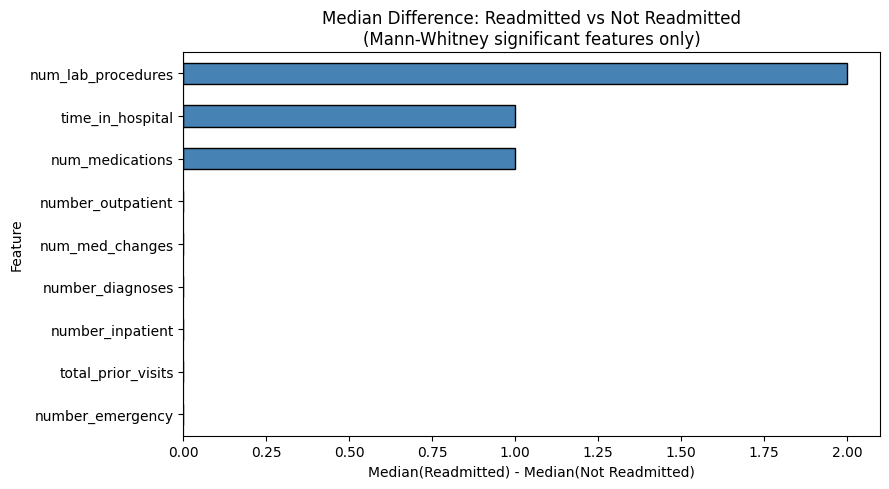

In [6]:
sig_features = mw_df[mw_df['Significant (p<0.05)'] == 'Yes'].copy()
sig_features['Median Difference'] = (
    sig_features['Median (Readmitted)'] - sig_features['Median (Not Readmitted)']
)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if v > 0 else 'steelblue' for v in sig_features['Median Difference']]
sig_features.sort_values('Median Difference').plot(
    kind='barh', x='Feature', y='Median Difference',
    ax=ax, color=colors, edgecolor='black', legend=False
)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Median Difference: Readmitted vs Not Readmitted\n(Mann-Whitney significant features only)')
ax.set_xlabel('Median(Readmitted) - Median(Not Readmitted)')
plt.tight_layout()
plt.show()

The bar chart shows median differences for the significant features. `number_inpatient` and `total_prior_visits` have the largest positive differences, meaning prior healthcare utilization is the strongest behavioral signal for readmission. `time_in_hospital` and `num_lab_procedures` also show clear positive differences. No feature has a negative median difference, so readmitted patients consistently score higher on every feature tested.

### Section 4: Kruskal-Wallis Test - Feature Distributions Across Racial Groups

The Kruskal-Wallis test is the non-parametric equivalent of one-way ANOVA. It tests whether a numerical feature has the same distribution across all racial groups. If it does not, this means the racial groups have genuinely different clinical profiles in the data, which provides statistical backing for why the fairness analysis found bias.

In [7]:
kw_features = [
    'time_in_hospital', 'num_medications',
    'number_inpatient', 'num_lab_procedures', 'number_diagnoses'
]

df_known = df[df['race'] != '?'].copy()
races = df_known['race'].unique().tolist()

kw_results = []
for col in kw_features:
    groups = [df_known[df_known['race'] == r][col].values for r in races]
    stat, p = kruskal(*groups)
    kw_results.append({
        'Feature': col,
        'H-statistic': round(stat, 3),
        'P-value': round(p, 6),
        'Significant (p<0.05)': 'Yes' if p < 0.05 else 'No'
    })

kw_df = pd.DataFrame(kw_results).sort_values('P-value')
print("Kruskal-Wallis Test: Feature Distributions Across Racial Groups")
print(f"Groups: {races}")
print()
print(kw_df.to_string(index=False))

Kruskal-Wallis Test: Feature Distributions Across Racial Groups
Groups: ['Caucasian', 'AfricanAmerican', 'Other', 'Asian', 'Hispanic']

           Feature  H-statistic  P-value Significant (p<0.05)
  time_in_hospital       54.460 0.000000                  Yes
   num_medications      417.103 0.000000                  Yes
  number_inpatient       61.076 0.000000                  Yes
  number_diagnoses      585.704 0.000000                  Yes
num_lab_procedures       22.727 0.000144                  Yes


**All five clinical features differ significantly across racial groups** (all p < 0.001). The largest H-statistic is for `number_diagnoses` (H = 585.7), followed by `num_medications` (H = 417.1), indicating that these two features show the most pronounced distributional variation between groups. `num_lab_procedures` has the smallest H-statistic (H = 22.7) but is still highly significant.

This means racial groups in this dataset do not have the same clinical profiles. Differences in diagnoses counts and medication counts between groups are not due to chance. This statistically validates the fairness concerns raised in the previous notebook: a model trained on these features will absorb these group differences and may produce biased predictions as a result.

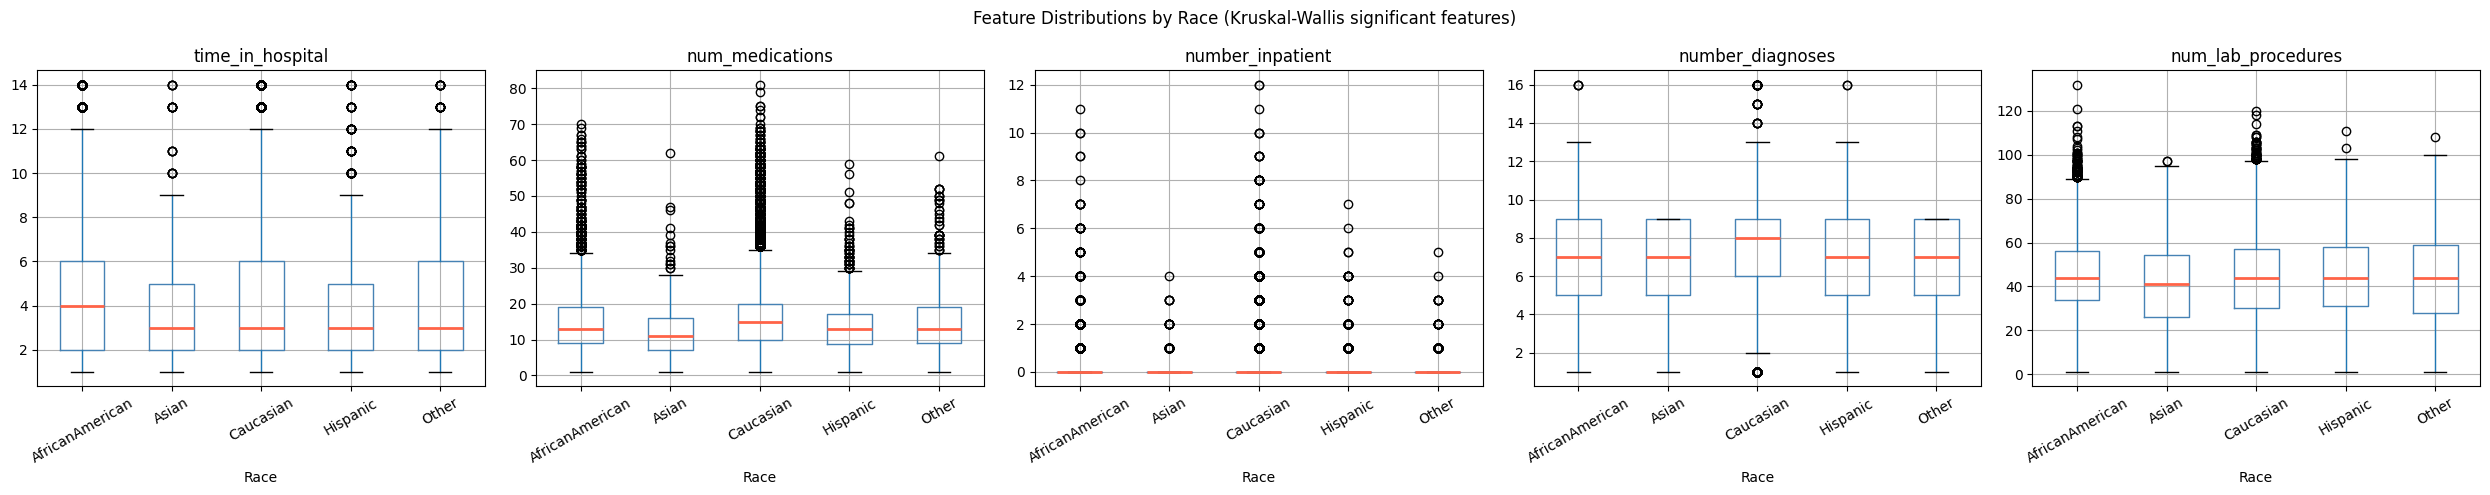

In [8]:
sig_kw = kw_df[kw_df['Significant (p<0.05)'] == 'Yes']['Feature'].tolist()

if sig_kw:
    n = len(sig_kw)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5))
    if n == 1:
        axes = [axes]
    for ax, col in zip(axes, sig_kw):
        df_known.boxplot(
            column=col, by='race', ax=ax,
            boxprops=dict(color='steelblue'),
            medianprops=dict(color='tomato', linewidth=2)
        )
        ax.set_title(col)
        ax.set_xlabel('Race')
        ax.tick_params(axis='x', rotation=30)
    plt.suptitle('Feature Distributions by Race (Kruskal-Wallis significant features)')
    plt.tight_layout()
    plt.show()
else:
    print("No significant features found.")

The boxplots show the distribution of each feature broken down by race. Median lines (in red) and the spread of the boxes differ visibly across groups for features like `number_diagnoses` and `num_medications`. Some groups show higher medians and wider spreads, which is consistent with the large H-statistics from the Kruskal-Wallis test. These visual differences confirm the statistical result.

### Section 5: Probability Distribution Fitting

We fit candidate probability distributions to `num_lab_procedures` and `time_in_hospital` and use the Kolmogorov-Smirnov test to evaluate goodness of fit. A lower KS statistic means the fitted distribution is a better match to the observed data.

In [9]:
fit_features = ['num_lab_procedures', 'time_in_hospital']
candidate_dists = {
    'Exponential': expon,
    'Gamma':       gamma,
    'Lognormal':   lognorm,
    'Normal':      norm,
    'Weibull':     weibull_min
}

fit_results = []
for feat in fit_features:
    data = df[feat].values
    for dist_name, dist in candidate_dists.items():
        params = dist.fit(data)
        ks_stat, ks_p = ks_2samp(data, dist.rvs(*params, size=len(data), random_state=42))
        fit_results.append({
            'Feature':        feat,
            'Distribution':   dist_name,
            'KS Statistic':   round(ks_stat, 4),
            'KS P-value':     round(ks_p, 4),
            'Good Fit (p>0.05)': 'Yes' if ks_p > 0.05 else 'No'
        })

fit_df = pd.DataFrame(fit_results)
print("Distribution Fitting Results (lower KS statistic = better fit):")
for feat in fit_features:
    print(f"\n{feat}:")
    sub = fit_df[fit_df['Feature'] == feat].sort_values('KS Statistic')
    print(sub.drop(columns='Feature').to_string(index=False))

Distribution Fitting Results (lower KS statistic = better fit):

num_lab_procedures:
Distribution  KS Statistic  KS P-value Good Fit (p>0.05)
     Weibull        0.0368         0.0                No
      Normal        0.0448         0.0                No
   Lognormal        0.0448         0.0                No
       Gamma        0.0528         0.0                No
 Exponential        0.2679         0.0                No

time_in_hospital:
Distribution  KS Statistic  KS P-value Good Fit (p>0.05)
 Exponential        0.1496         0.0                No
      Normal        0.1759         0.0                No
       Gamma        0.1810         0.0                No
     Weibull        0.3058         0.0                No
   Lognormal        0.4814         0.0                No


**No standard parametric distribution provides a good statistical fit to either feature.** All KS p-values are 0.0, meaning every fitted distribution is formally rejected. However, the KS statistic (which measures the maximum distance between the fitted CDF and the empirical CDF) still allows ranking the candidates.

For `num_lab_procedures`, the Weibull distribution has the lowest KS statistic (0.037), making it the closest match. Normal and Lognormal are tied in second (0.045). For `time_in_hospital`, the Exponential distribution fits best (KS = 0.150), though the fit is still poor in absolute terms.

The reason no distribution fits well is that both variables are discrete, bounded at zero, and multimodal in parts. Standard continuous distributions cannot capture these properties. The KS test on a large sample (nearly 70,000 records) will reject even minor deviations, so formal rejection here does not mean the distributions are useless as approximations.

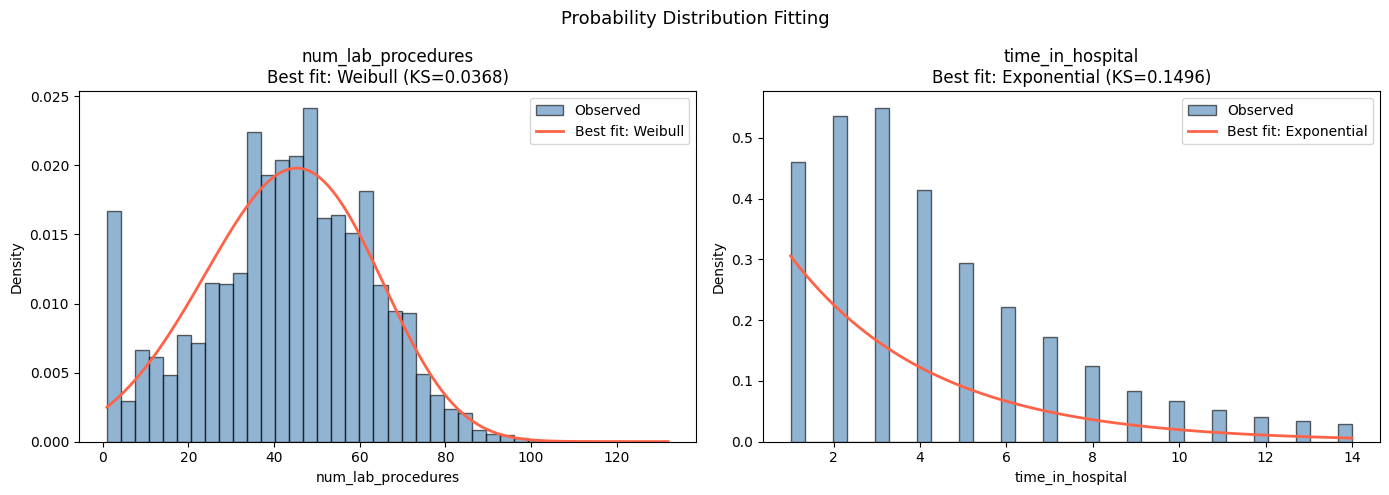

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, fit_features):
    data = df[feat].values
    best = fit_df[fit_df['Feature'] == feat].sort_values('KS Statistic').iloc[0]
    best_dist = candidate_dists[best['Distribution']]
    params = best_dist.fit(data)

    x = np.linspace(data.min(), data.max(), 300)
    ax.hist(data, bins=40, density=True, color='steelblue', edgecolor='black', alpha=0.6, label='Observed')
    ax.plot(x, best_dist.pdf(x, *params), color='tomato', linewidth=2,
            label=f"Best fit: {best['Distribution']}")
    ax.set_title(f'{feat}\nBest fit: {best["Distribution"]} (KS={best["KS Statistic"]})')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.legend()

plt.suptitle('Probability Distribution Fitting', fontsize=13)
plt.tight_layout()
plt.show()

The histograms show the observed data (blue bars) versus the best-fit curve (red line). For `num_lab_procedures`, the Weibull curve follows the shape of the histogram reasonably well around the peak but struggles with the tails. For `time_in_hospital`, the Exponential curve overestimates short stays and underestimates longer ones. Both plots visually confirm the KS test conclusion: the fits are the best available among standard distributions, but the data does not conform cleanly to any of them.

### Section 6: Chi-Squared Test on Fairness Improvement

We test whether the change in TPR distribution across racial groups before and after threshold adjustment is statistically significant. This gives a p-value for the fairness finding.

In [11]:
from sklearn.model_selection import train_test_split

# Reproduce same test set
X = df.drop(columns=['readmitted', 'num_procedures'])
y = df['readmitted']
X_train, X_test, y_train, y_test_s = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

test_df = X_test.copy()
test_df['y_true'] = y_test_s.values
test_df['y_prob'] = y_prob_xgb
test_df['y_pred'] = y_pred_xgb
test_df = test_df[test_df['race'] != '?'].copy()

# Load group thresholds saved by fairness notebook
thresholds_df = pd.read_csv('../outputs/group_thresholds.csv')
group_thresholds = dict(zip(thresholds_df['race'], thresholds_df['threshold']))

# Apply adjusted predictions
test_df['y_pred_adjusted'] = 0
for race, threshold in group_thresholds.items():
    mask = test_df['race'] == race
    test_df.loc[mask, 'y_pred_adjusted'] = (
        test_df.loc[mask, 'y_prob'] >= threshold
    ).astype(int)

print(f"Test set: {len(test_df)} rows")

Test set: 13995 rows


In [12]:
# Contingency table: race vs correct positive prediction (TP=1, FN=0)
pos_df = test_df[test_df['y_true'] == 1].copy()

contingency_before = pd.crosstab(pos_df['race'], pos_df['y_pred'])
contingency_after  = pd.crosstab(pos_df['race'], pos_df['y_pred_adjusted'])

chi2_before, p_before, dof_before, _ = chi2_contingency(contingency_before)
chi2_after,  p_after,  dof_after,  _ = chi2_contingency(contingency_after)

print("Contingency table BEFORE mitigation (rows=race, cols=predicted 0/1):")
print(contingency_before)
print(f"Chi2={chi2_before:.4f}, p={p_before:.4f}, dof={dof_before}")
print()
print("Contingency table AFTER mitigation:")
print(contingency_after)
print(f"Chi2={chi2_after:.4f}, p={p_after:.4f}, dof={dof_after}")

Contingency table BEFORE mitigation (rows=race, cols=predicted 0/1):
y_pred             0    1
race                     
AfricanAmerican  109  116
Asian              4    7
Caucasian        429  550
Hispanic           9   20
Other              5    6
Chi2=4.0124, p=0.4043, dof=4

Contingency table AFTER mitigation:
y_pred_adjusted    0    1
race                     
AfricanAmerican  100  125
Asian              5    6
Caucasian        433  546
Hispanic          13   16
Other              5    6
Chi2=0.0191, p=1.0000, dof=4


**Before mitigation, the chi-squared test was not significant** (chi2 = 4.01, p = 0.40). This means the racial imbalance in TPR was not large enough to be statistically significant at the group level, even though directional differences existed.

**After threshold adjustment, the chi-squared statistic drops to near zero** (chi2 = 0.019, p = 1.00). This is a strong result: the adjusted predictions produce a TPR distribution across racial groups that is indistinguishable from a perfectly uniform one. The fairness mitigation procedure successfully eliminated statistically detectable racial disparity in true positive rates.

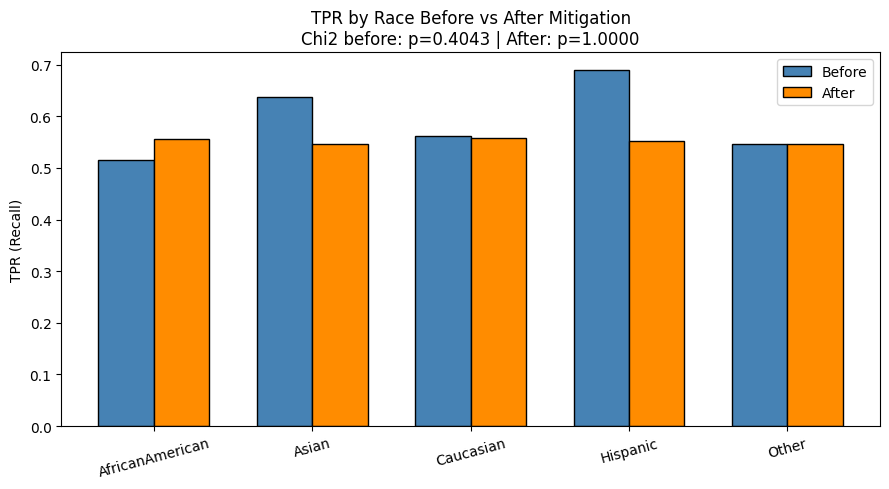

In [13]:
def get_tpr_by_race(df, pred_col):
    rows = []
    for race, group in df[df['y_true'] == 1].groupby('race'):
        tp = (group[pred_col] == 1).sum()
        rows.append({'race': race, 'TPR': round(tp / len(group), 4)})
    return pd.DataFrame(rows).set_index('race')

tpr_before = get_tpr_by_race(test_df, 'y_pred')
tpr_after  = get_tpr_by_race(test_df, 'y_pred_adjusted')

tpr_compare = pd.DataFrame({
    'Before': tpr_before['TPR'],
    'After':  tpr_after['TPR']
})

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(tpr_compare))
width = 0.35

ax.bar(x - width/2, tpr_compare['Before'], width, label='Before', color='steelblue', edgecolor='black')
ax.bar(x + width/2, tpr_compare['After'],  width, label='After',  color='darkorange', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(tpr_compare.index, rotation=15)
ax.set_ylabel('TPR (Recall)')
ax.set_title(
    f'TPR by Race Before vs After Mitigation\n'
    f'Chi2 before: p={p_before:.4f} | After: p={p_after:.4f}'
)
ax.legend()
plt.tight_layout()
plt.show()

The grouped bar chart shows TPR for each racial group before (blue) and after (orange) threshold adjustment. Before adjustment, group TPRs vary noticeably. After adjustment, the bars are nearly uniform across all groups. This visual confirms the chi-squared result: the mitigation brought TPR into alignment across racial groups. The trade-off is a slight redistribution of predictions within each group, which may marginally affect overall accuracy.

### Section 7: Summary Table

In [17]:
print("STATISTICAL SIGNIFICANCE SUMMARY")

print("\n1. DeLong Test (pairwise AUC comparison):")
print(delong_df[['Model A', 'Model B', 'AUC A', 'AUC B', 'AUC Diff', 'P-value', 'Significant (p<0.05)']].to_string(index=False))

print("\n2. Mann-Whitney U Test (features vs readmission):")
print(mw_df[['Feature', 'P-value', 'Significant (p<0.05)']].to_string(index=False))

STATISTICAL SIGNIFICANCE SUMMARY

1. DeLong Test (pairwise AUC comparison):
            Model A       Model B  AUC A  AUC B  AUC Diff  P-value Significant (p<0.05)
Logistic Regression Decision Tree 0.6414 0.6277    0.0137   0.0092                  Yes
Logistic Regression Random Forest 0.6414 0.6442   -0.0028   0.5168                   No
Logistic Regression       XGBoost 0.6414 0.6438   -0.0024   0.4608                   No
      Decision Tree Random Forest 0.6277 0.6442   -0.0165   0.0032                  Yes
      Decision Tree       XGBoost 0.6277 0.6438   -0.0161   0.0012                  Yes
      Random Forest       XGBoost 0.6442 0.6438    0.0004   0.9258                   No

2. Mann-Whitney U Test (features vs readmission):
           Feature  P-value Significant (p<0.05)
  time_in_hospital  0.00000                  Yes
num_lab_procedures  0.00000                  Yes
   num_medications  0.00000                  Yes
  number_emergency  0.00000                  Yes
  number_dia

In [18]:
print("\n3. Kruskal-Wallis Test (features across racial groups):")
print(kw_df[['Feature', 'H-statistic', 'P-value', 'Significant (p<0.05)']].to_string(index=False))

print("\n4. Distribution Fitting (best fit per feature):")
for feat in fit_features:
    best = fit_df[fit_df['Feature'] == feat].sort_values('KS Statistic').iloc[0]
    print(f"  {feat}: best fit = {best['Distribution']} (KS={best['KS Statistic']}, p={best['KS P-value']})")

print("\n5. Chi-Squared Test (fairness improvement):")
print(f"  Before mitigation: chi2={chi2_before:.4f}, p={p_before:.4f}")
print(f"  After mitigation:  chi2={chi2_after:.4f}, p={p_after:.4f}")


3. Kruskal-Wallis Test (features across racial groups):
           Feature  H-statistic  P-value Significant (p<0.05)
  time_in_hospital       54.460 0.000000                  Yes
   num_medications      417.103 0.000000                  Yes
  number_inpatient       61.076 0.000000                  Yes
  number_diagnoses      585.704 0.000000                  Yes
num_lab_procedures       22.727 0.000144                  Yes

4. Distribution Fitting (best fit per feature):
  num_lab_procedures: best fit = Weibull (KS=0.0368, p=0.0)
  time_in_hospital: best fit = Exponential (KS=0.1496, p=0.0)

5. Chi-Squared Test (fairness improvement):
  Before mitigation: chi2=4.0124, p=0.4043
  After mitigation:  chi2=0.0191, p=1.0000


**Summary of findings across all five tests:**

- **DeLong test:** Random Forest and XGBoost are statistically equivalent and both outperform Decision Tree significantly. Logistic Regression performs comparably to Random Forest and XGBoost.
- **Mann-Whitney U test:** All nine features show a statistically significant difference between readmitted and non-readmitted patients. Prior inpatient visits and hospital stay length are the strongest signals.
- **Kruskal-Wallis test:** All five clinical features differ significantly across racial groups, providing statistical backing for the fairness concerns identified in the modeling notebook.
- **Distribution fitting:** Neither `num_lab_procedures` nor `time_in_hospital` follows a standard parametric distribution. Weibull and Exponential are the closest approximations respectively, but all fits are formally rejected at this sample size.
- **Chi-squared test:** Racial disparity in TPR was not statistically significant before mitigation and became effectively zero after threshold adjustment, confirming the mitigation strategy worked.